In [1]:
from pathlib import Path
import pandas as pd
import numpy as np

def get_avg_keypoints(csv_path, min_vis=0.9):
    '''
    Computes the average keypoint value. Only takes keypoints with visability >= min_vis.
    '''
    court = pd.read_csv(csv_path)

    vis_cols = [
        'front_left_vis', 'mid_left_vis', 'mid_right_vis',
        'front_right_vis', 'service_right_vis', 'service_left_vis',
    ]
    mask = (court[vis_cols] >= min_vis).all(axis=1)

    # print(f'Before filtering: {court.shape}')
    filtered = court[mask]
    # print(f'After filtering: {filtered.shape}')

    coord_cols = [
        'front_left_x', 'front_left_y',
        'mid_left_x', 'mid_left_y',
        'mid_right_x', 'mid_right_y',
        'front_right_x', 'front_right_y',
        'service_right_x', 'service_right_y',
        'service_left_x', 'service_left_y',
    ]
    avg_keypoints = filtered[coord_cols].mean()
    return avg_keypoints

def map_3dcoords(detected_coords):
    ''' 
    Maps real world squash coordinates to the tracked coordinates. Units are in meters
    for the court dimension, pixels for the incoming tracked coordinates. 
    X-dimension is across the court width wise (with negative being to the left), Y-dimnesion is front to back of the court (with negative being behind the shortline), Z-dimension is height (with 0 at the floor height).
    Thus, (0,0,0) is at the center of the T. 

    Args:
        detected_coords: The computed coordinates corresponding to the 6 court keypoints.

    Returns:
        P: The matrix that takes 3D world coords to 2D camera coords
    '''
    court_dims = {'front_left_x' : -3.2, 'front_left_y' : 5.44, 'front_left_z' : 0,
                  'front_right_x' : 3.2, 'front_right_y' : 5.44, 'front_right_z' : 0,
                  'mid_left_x' : -3.2, 'mid_left_y' : 0, 'mid_left_z' : 0,
                  'mid_right_x' : 3.2, 'mid_right_y' : 0, 'mid_right_z' : 0,
                  'service_left_x' : -3.2, 'service_left_y' : 5.44, 'service_left_z' : 1.78,
                  'service_right_x' : 3.2, 'service_right_y' : 5.44, 'service_right_z' : 1.78
                }

    keypoints = ['front_left', 'front_right', 'mid_left', 'mid_right', 'service_left', 'service_right']

    # 6x3 array of the court coordinates in real life
    world_pts = np.array([
        [court_dims[f'{kp}_x'], court_dims[f'{kp}_y'], court_dims[f'{kp}_z']]
        for kp in keypoints
    ])

    # 6x2 array of detected keypoints
    image_pts = np.array([
        [detected_coords[f'{kp}_x'], detected_coords[f'{kp}_y']]
        for kp in keypoints
    ])

    # Build the DLT matrix A (2N x 12)
    A = []
    for (X, Y, Z), (u, v) in zip(world_pts, image_pts):
        A.append([X, Y, Z, 1,  0, 0, 0, 0, -u*X, -u*Y, -u*Z, -u])
        A.append([0, 0, 0, 0,  X, Y, Z, 1, -v*X, -v*Y, -v*Z, -v])
    A = np.array(A)

    # Solve: last row of V^T (row corresponding to smallest singular value)
    _, _, Vt = np.linalg.svd(A)
    P = Vt[-1].reshape(3, 4)

    return P

def project_points(P, world_pts):
    '''Projects a 3D homogeneous world point through P, returns (u, v) coordinates
    
    Args:
        P: matrix that projects 3D homogeneous world point --> 2D (u,v) coords
        world_pt: One or a list of 3D points in homogeneous coords

    Returns:
        Returns a list of (u,v) coords
    '''
    pts = np.atleast_2d(world_pts)     # (N, 4)
    pt_h = (P @ pts.T)                # (3, N)
    u, v = pt_h[0] / pt_h[2], pt_h[1] / pt_h[2]
    return list(zip(u, v))

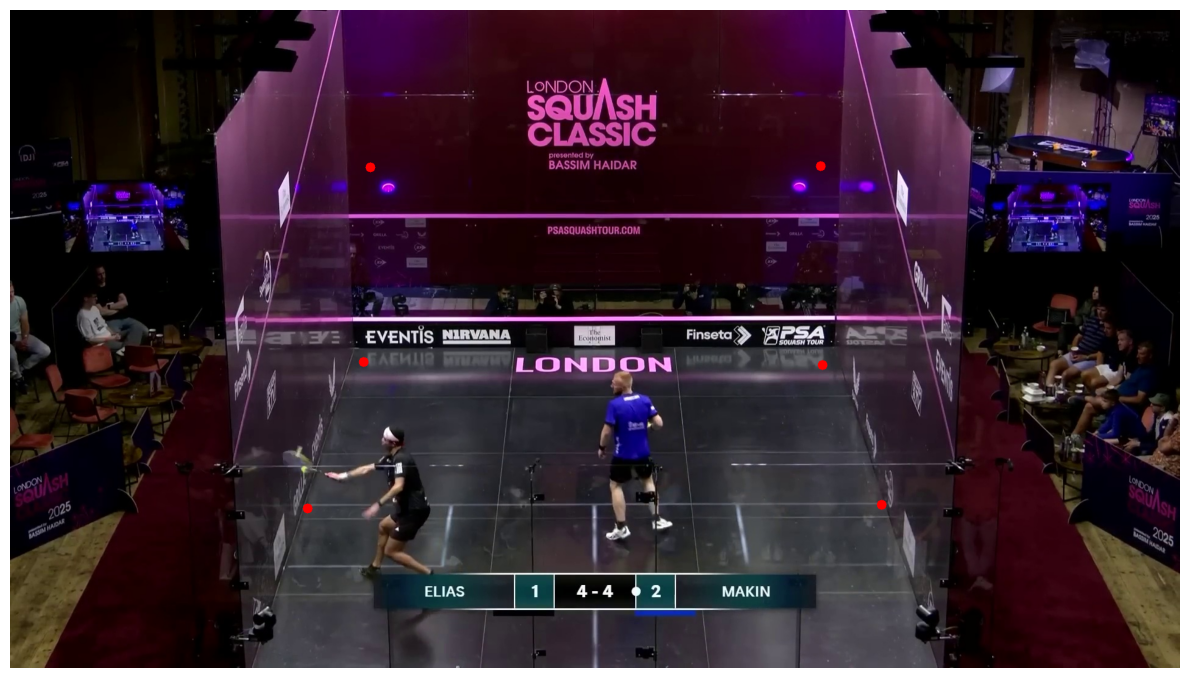

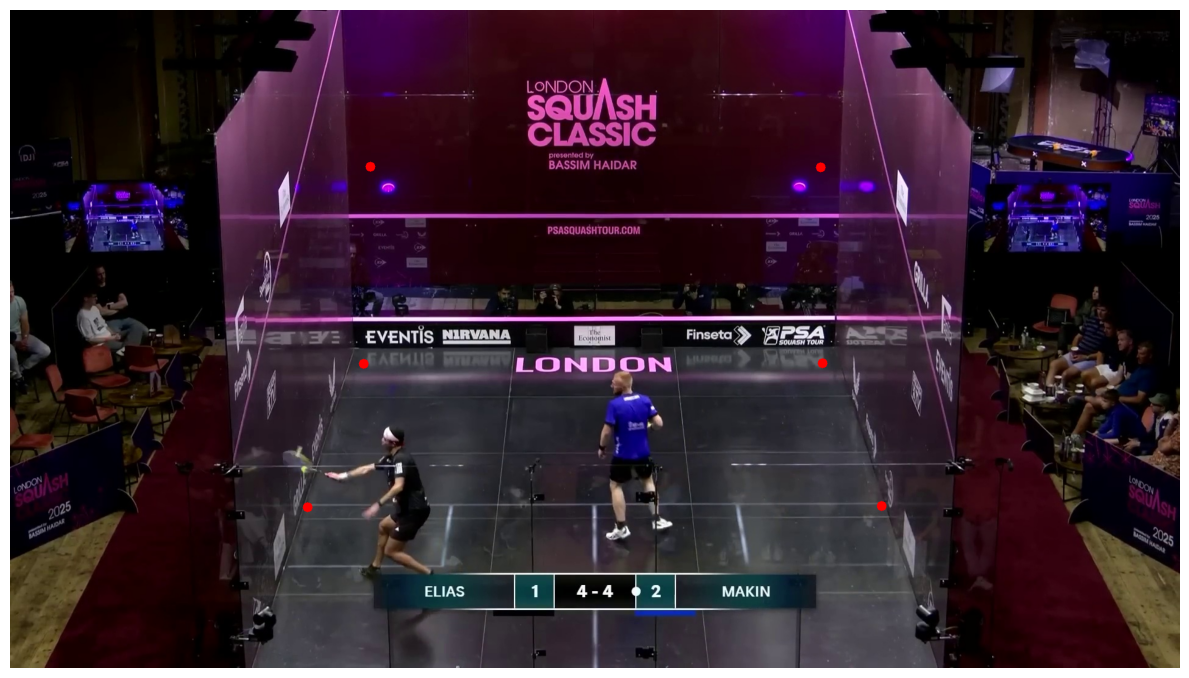

[[ 1.68577072e-02 -2.76158020e+00]
 [-8.45578406e+02  2.37224599e+02]
 [ 9.42809652e+02 -3.28493041e+00]
 [-9.72687602e+01 -2.31198590e+02]
 [ 7.38831332e+02 -8.63384848e-01]
 [-7.38831479e+02  8.68174239e-01]]


In [4]:
from visualizer import visualize_court_points

def pairwise(iterable):
    it = iter(iterable)
    return list(zip(it, it))

### testing finding average points
test_path = 'predictions/rally6_v2/court_keypoints.csv'
avg = get_avg_keypoints(test_path)
# print(avg)
points = pairwise(avg.values)
visualize_court_points(points) # visualize doesn't work on command line

### Testing Projection Matrix
P = map_3dcoords(avg)
court_points = [[-3.2, 5.44, 0], [3.2, 5.44, 0], [-3.2, 0, 0], [3.2, 0, 0], [-3.2, 5.44, 1.78], [3.2, 5.44, 1.78]]
court_points = [points + [1] for points in court_points]
proj_court_points = project_points(P, court_points)
visualize_court_points(proj_court_points)

### demonstrates error of projection
print(np.array(points) - np.array(proj_court_points))